In [1]:
import json
import pathlib
from pprint import pprint

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.spatial.distance import squareform

import bonsai_loop as bl

sc.set_figure_params(figsize=(5, 5))  # type: ignore[call-arg]
sc.set_figure_params(figsize=(5, 5))  # type: ignore[call-arg]

/home/stan/Git/bonsai-loop/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import inspect

from bonsai_loop.bonsai_lib.bonsai.bonsai_dataprocessing import (  # type: ignore[import]
    loadReconstructedTreeAndData,
)
from bonsai_loop.bonsai_lib.bonsai.bonsai_helpers import (  # type: ignore[import]
    Run_Configs,
)

print(inspect.getsource(loadReconstructedTreeAndData))
print(f"{'─' * 88}")
pprint(Run_Configs.__dict__)

def loadReconstructedTreeAndData(args, tree_folder, reprocess_data=False, all_genes=False, all_ranks=True,
                                 get_cell_info=False, corrected_data=True, rel_to_results=False, no_data_needed=False,
                                 single_process=False, keep_original_data=False, calc_loglik=False, get_data=True,
                                 get_posterior_ltqs=False, otherRanksMinimalInfo=False, verbose=True,
                                 calc_posteriors=True):
    """

    :param args:
    :param tree_folder:
    :param reprocess_data:
    :param all_genes:
    :param all_ranks:
    :param get_cell_info:
    :param corrected_data:
    :param rel_to_results:
    :param no_data_needed:
    :param single_process:
    :param keep_original_data:
    :param calc_loglik:
    :param get_data:
    :param get_posterior_ltqs:
    :param otherRanksMinimalInfo:
    :param verbose:
    :param calc_posteriors: This boolean may be false, even when get_posterior_ltqs i

# Reconstruct tree

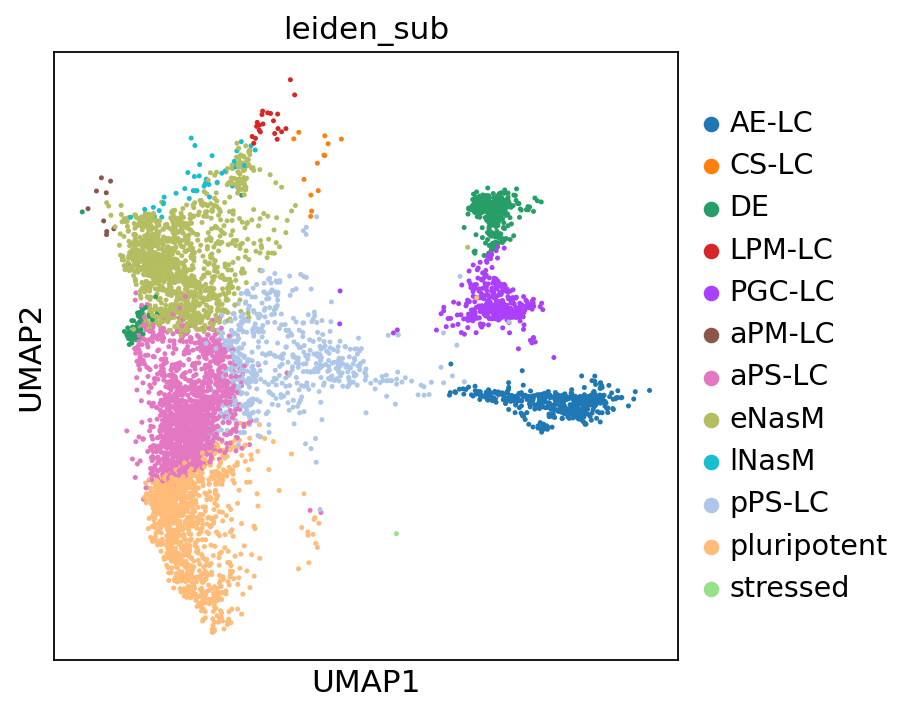

33776

In [3]:
import gc

data_path = pathlib.Path("./data")
adata = sc.read_h5ad(data_path / "adata_timeseries_old_48h-1.h5ad")
meta = pd.read_csv(data_path / "adata_timeseries_old_48h-1_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index]
adata.obsm["X_umap"] = np.array(
    adata.obs.loc[:, ["umap_old_48-96h_x", "umap_old_48-96h_y"]]
)
sc.pl.umap(adata, color=["leiden_sub"])
del meta
bonsai_gastruloid_path = data_path / "Bonsai_48h-1"
gas_bonsai_output_folder = bonsai_gastruloid_path / "final_bonsai_zscore0.75/"
gas_bonsai_config_file = bonsai_gastruloid_path / "used_run_configs.yaml"
gc.collect()

In [4]:
gas_run_configs = Run_Configs(gas_bonsai_config_file)
scData, vert_map = loadReconstructedTreeAndData(
    gas_run_configs,
    gas_bonsai_output_folder,
    rel_to_results=False,
    reprocess_data=False,
    all_ranks=False,
    get_cell_info=True,
    get_posterior_ltqs=True,
)
# compute dsLeafs for dendrogram
scData.tree.root.get_ds_info_for_ladderize()
print(f"{'─' * 88}")
print(scData.tree)
print(f"{'─' * 88}")
print(scData.tree.root)

04-30 03:30:41 mp_print INFO 

Reconstructed tree loaded from: 
data/Bonsai_48h-1/final_bonsai_zscore0.75/edgeInfo.txt 
data/Bonsai_48h-1/final_bonsai_zscore0.75/vertInfo.txt


────────────────────────────────────────────────────────────────────────────────────────
Tree(root=TreeNode(
nodeInd = -1 
nodeId = 'root' 
 childNodes = [5927, 8477] 
 parentNode = None 
tParent = None 
isLeaf = False 
isRoot = True 
isCell = False 
ltqs = None 
_ltqsVars = None 
_W_g = None 
ltqsAIRoot = memmap([ -9.96530558, -11.01004528, -10.04425584, ...,  -8.84288488,
         -9.04318264,  -9.12560264]) 
_ltqsVarsAIRoot = memmap([0.0201755 , 0.02502109, 0.02183851, ..., 0.01829026, 0.01825829,
        0.01790025]) 
_W_gAIRoot = None 
prefactor = None 
dLoglikdtParent = None 
nnnLoglik = None 
cumClosenessNNN = None 
)

loglik=None,nNodes=11069)
────────────────────────────────────────────────────────────────────────────────────────
TreeNode(
nodeInd = -1 
nodeId = 'root' 
 childNodes = [5927, 8477] 
 parentNode = None 
tParent = None 
isLeaf = False 
isRoot = True 
isCell = False 
ltqs = None 
_ltqsVars = None 
_W_g = None 
ltqsAIRoot = memmap([ -9.96530558, -11.01004528, -10.04

## Reroot

In [5]:
gas_node_id_to_vert_ind = {}
with open(gas_bonsai_output_folder / "vertInfo.txt") as f:
    next(f)
    for line in f:
        parts = line.strip().split("\t")
        gas_node_id_to_vert_ind[parts[2]] = int(parts[0])
pprint(dict(list(gas_node_id_to_vert_ind.items())[:15]))

{'ACTCCCACAAGCGGAT-1_48h': 3,
 'CCACCATAGCTCTTCC-1_48h': 12,
 'CCGATCTCAAGCTCTA-1_48h': 14,
 'CCGGTAGTCCCTCTAG-1_48h': 7,
 'CGGGACTGTCCACAGC-1_48h': 10,
 'TCAAGTGTCTGTCAGA-1_48h': 4,
 'internal_0': 1,
 'internal_1': 2,
 'internal_2': 5,
 'internal_3': 6,
 'internal_4': 8,
 'internal_5': 9,
 'internal_6': 11,
 'internal_7': 13,
 'root': 0}


In [6]:
print(scData.tree.root)
print(f"{'─' * 88}")
print(
    f"root has {scData.tree.root.dsLeafs} leaves, should be the same as the total number of real cells"
)

TreeNode(
nodeInd = -1 
nodeId = 'root' 
 childNodes = [5927, 8477] 
 parentNode = None 
tParent = None 
isLeaf = False 
isRoot = True 
isCell = False 
ltqs = None 
_ltqsVars = None 
_W_g = None 
ltqsAIRoot = memmap([ -9.96530558, -11.01004528, -10.04425584, ...,  -8.84288488,
         -9.04318264,  -9.12560264]) 
_ltqsVarsAIRoot = memmap([0.0201755 , 0.02502109, 0.02183851, ..., 0.01829026, 0.01825829,
        0.01790025]) 
_W_gAIRoot = None 
prefactor = None 
dLoglikdtParent = None 
nnnLoglik = None 
cumClosenessNNN = None 
)
────────────────────────────────────────────────────────────────────────────────────────
root has 5927 leaves, should be the same as the total number of real cells


In [7]:
new_root = "internal_1880"
scData.tree.reset_root(gas_node_id_to_vert_ind[new_root])

In [8]:
# root should be updated
scData.tree.root

TreeNode(
nodeInd = 7807 
nodeId = 'internal_1880' 
 childNodes = [223, 698, 7808, 7806] 
 parentNode = None 
tParent = None 
isLeaf = False 
isRoot = True 
isCell = False 
ltqs = None 
_ltqsVars = None 
_W_g = None 
ltqsAIRoot = memmap([ -9.18113682, -11.03625705, -10.18330031, ...,  -9.78656951,
         -9.21618151,  -8.34801305]) 
_ltqsVarsAIRoot = memmap([0.01290147, 0.02082892, 0.0168208 , ..., 0.01405451, 0.01217697,
        0.0101181 ]) 
_W_gAIRoot = None 
prefactor = None 
dLoglikdtParent = None 
nnnLoglik = None 
cumClosenessNNN = None 
)

## 

## Contact maps by level

### Bonsai clustering 

In [9]:
f = h5py.File(bonsai_gastruloid_path / "bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]  # type: ignore[index]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]  # type: ignore[index]
cell_inds = f["tree_info/cell_inds"][:]  # type: ignore[index]
int_inds = f["tree_info/int_inds"][:]  # type: ignore[index]
metadata = json.loads(f.attrs["metadata_json"])  # type: ignore[index]
gas_cell_ids = metadata["cellIds"]  # type: ignore[index]
gas_vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])  # type: ignore[index]

cell_coords = np.zeros((len(gas_cell_ids), 2))
for vert_idx_str, cell_idx in gas_vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]  # type: ignore[index]
    else:
        cell_coords[cell_idx] = coords[vert_idx]  # type: ignore[index]
adata.obsm["X_bonsai"] = cell_coords
f.close()

<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

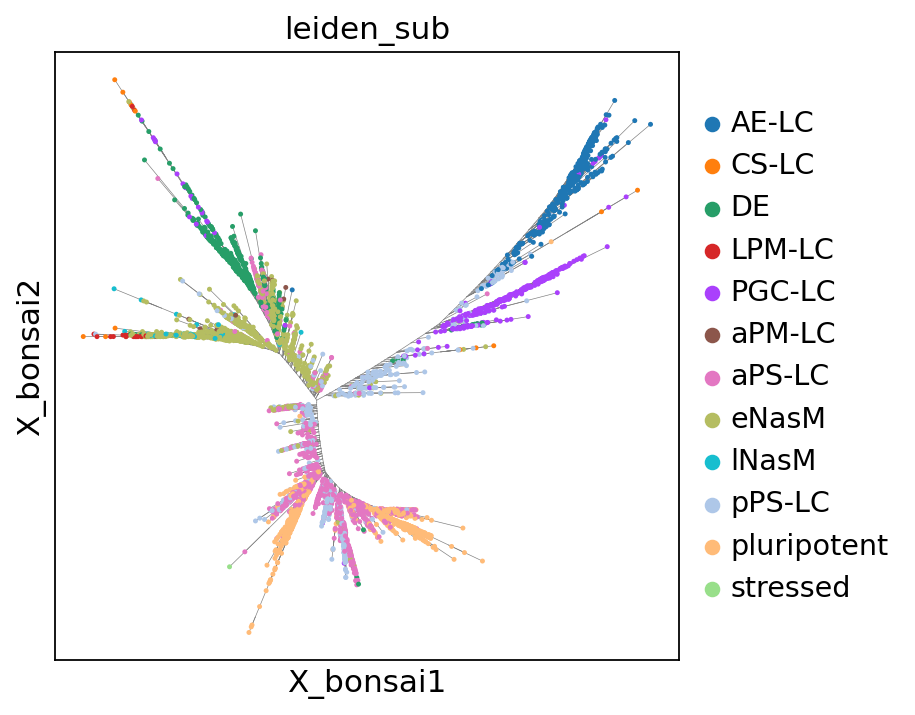

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:  # type: ignore[index]
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="leiden_sub", ax=ax, show=False, s=20, zorder=2
)

In [11]:
from bonsai_loop.bonsai_lib import bonsai_clustering  # type: ignore[import]

with open(gas_bonsai_output_folder / "tree.nwk") as f:
    nwk_str = f.read().strip()
all_clusters, _ = bonsai_clustering.get_min_pdists_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, n_clusters=10
)
gas_clusters = all_clusters[f"annot_bnsi_cluster_n{10}"]
cluster_dict = bonsai_clustering.get_cluster_assignments({"annot": gas_clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

if "bonsai_cluster_colors" in adata.uns:
    del adata.uns["bonsai_cluster_colors"]

04-30 03:30:54 mp_print INFO 
Init min-dist clustering-tree
04-30 03:30:54 mp_print INFO Clustering has created 2 subtrees, 8 branches still to cut.
04-30 03:30:54 mp_print INFO Clustering has created 4 subtrees, 6 branches still to cut.
04-30 03:30:54 mp_print INFO Clustering has created 8 subtrees, 2 branches still to cut.


Clustering done


<Axes: title={'center': 'bonsai_cluster'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

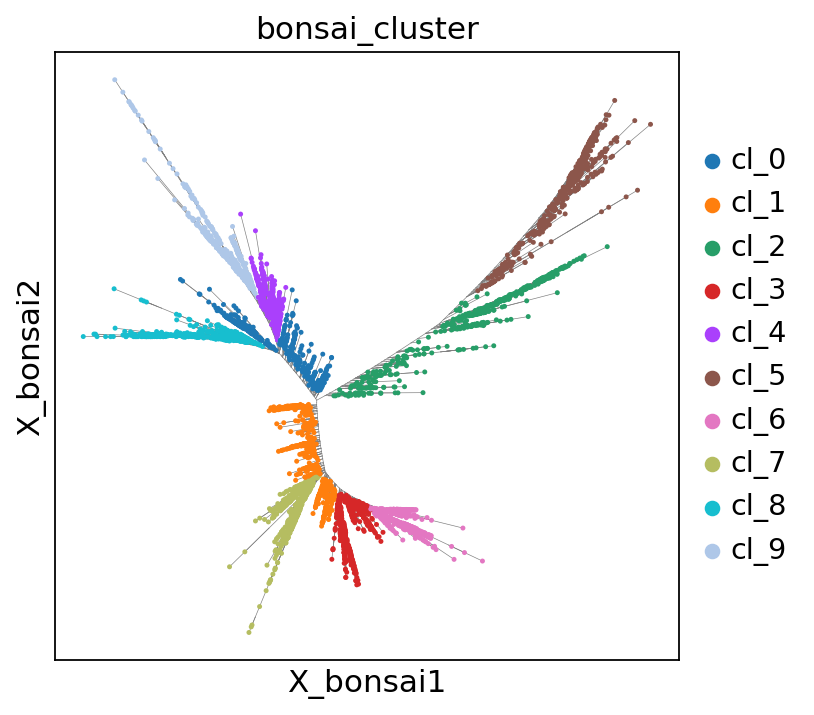

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:  # type: ignore[index]
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="bonsai_cluster", ax=ax, show=False, s=20, zorder=2
)

### Compute node level and label

In [13]:
node_data_lookup = bl.convergence.compute_tree_node_level_and_label(
    tree=scData.tree,
    node_level_type="topological",
    label_lookup_leaves=adata.obs["bonsai_cluster"].to_dict(),
)

compute depth-first ordering of nodes
root node internal_1880
compute node level and label


11069it [00:00, 321668.60it/s]


In [14]:
# root node should have n_leaves = number of real cells (n=5927)
print(node_data_lookup["internal_1880"])
# a real cell (a leaf) should have n_leaves = 1
print(node_data_lookup["TTTGTTGTCCATTTCA-1_48h"])

┌───────────────────┬──────────────────────────────────────────────┐
│ attribute         │ value                                        │
├───────────────────┼──────────────────────────────────────────────┤
│ tree_node         │ TreeNode(nodeId='internal_1880')             │
│ topological_level │ 195                                          │
│ geometric_level   │ None                                         │
│ identity          │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves          │ 5927                                         │
│ ordering_value    │ None                                         │
│ dendrogram_coords │ None                                         │
│ other_props       │ None                                         │
└───────────────────┴──────────────────────────────────────────────┘
┌───────────────────┬───────────────────────────────────────────┐
│ attribute         │ value                                     │
├───────────────────┼───────────────────

### Compute node ordering

In [15]:
bl.convergence.compute_node_ordering_value(
    tree=scData.tree,
    node_data_lookup=node_data_lookup,
)

compute node ordering using metric bonsai_t_to_root


In [16]:
ordering_leaves = bl.convergence.compute_node_ordering(
    node_data_lookup=node_data_lookup,
    level=0,
    sort_by_identity_first=True,
    ascending=True,
)
pprint(ordering_leaves[:5])

['AGACAGGAGCCTATTG-1_48h',
 'GCCATGGCAAGTTTGC-1_48h',
 'AAGGAATAGAGCAGTC-1_48h',
 'GCACGGTGTTATAGAG-1_48h',
 'GGGACAATCAGTCCGG-1_48h']


In [17]:
# check ordering value
# root node should have ordering_value = 0
print(node_data_lookup["internal_1880"])
# a real cell (a leaf) should have ordering_value > 0
print(node_data_lookup["TTTGTTGTCCATTTCA-1_48h"])

┌───────────────────┬──────────────────────────────────────────────┐
│ attribute         │ value                                        │
├───────────────────┼──────────────────────────────────────────────┤
│ tree_node         │ TreeNode(nodeId='internal_1880')             │
│ topological_level │ 195                                          │
│ geometric_level   │ None                                         │
│ identity          │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves          │ 5927                                         │
│ ordering_value    │ 0                                            │
│ dendrogram_coords │ None                                         │
│ other_props       │ None                                         │
└───────────────────┴──────────────────────────────────────────────┘
┌───────────────────┬───────────────────────────────────────────┐
│ attribute         │ value                                     │
├───────────────────┼───────────────────

### Compute dendrogram

In [18]:
bl.convergence.compute_bonsai_tree_dendrogram(
    tree=scData.tree,
    node_data_lookup=node_data_lookup,
    ladderize_by_annotated_leaves_only=True,  # in this case all cells are annotated so this wont matter
)

In [19]:
# check dendrogram
print(node_data_lookup["internal_1880"])
print(node_data_lookup["TTTGTTGTCCATTTCA-1_48h"])

┌───────────────────┬──────────────────────────────────────────────┐
│ attribute         │ value                                        │
├───────────────────┼──────────────────────────────────────────────┤
│ tree_node         │ TreeNode(nodeId='internal_1880')             │
│ topological_level │ 195                                          │
│ geometric_level   │ None                                         │
│ identity          │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves          │ 5927                                         │
│ ordering_value    │ 0                                            │
│ dendrogram_coords │ (-0.95, -0.9159482420614774)                 │
│ other_props       │ None                                         │
└───────────────────┴──────────────────────────────────────────────┘
┌───────────────────┬───────────────────────────────────────────┐
│ attribute         │ value                                     │
├───────────────────┼───────────────────

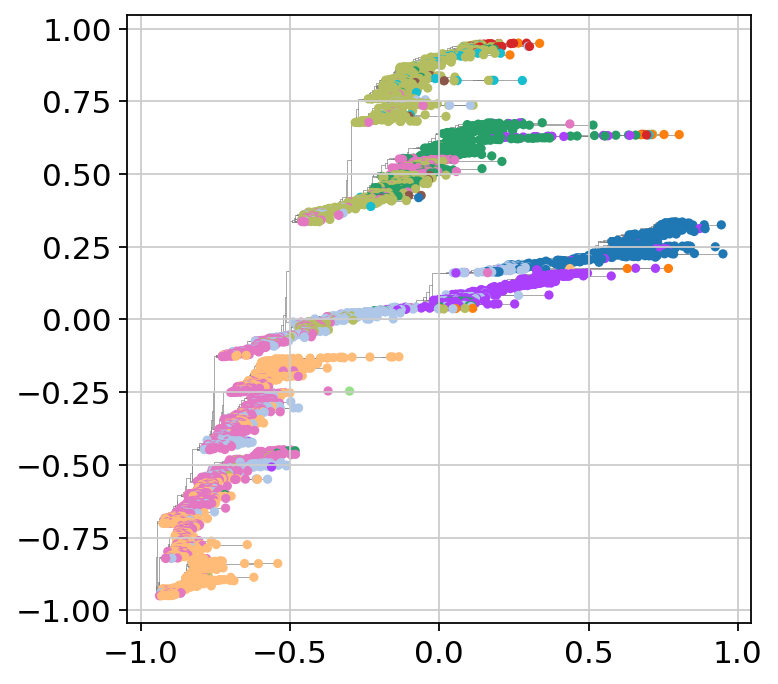

In [20]:
# verify that the dendrogram is correct
edge_df = scData.tree.get_edge_dataframe()
sources = edge_df["source"].to_list()
targets = edge_df["target"].to_list()

gas_edge_coords_d = np.zeros((len(sources), 3, 2))
for i, (s, t) in enumerate(zip(sources, targets)):
    gas_edge_coords_d[i, 0, :] = node_data_lookup[s].dendrogram_coords
    gas_edge_coords_d[i, 2, :] = node_data_lookup[t].dendrogram_coords
    gas_edge_coords_d[i, 1, 0] = node_data_lookup[s].dendrogram_coords[0]  # type: ignore[index]
    gas_edge_coords_d[i, 1, 1] = node_data_lookup[t].dendrogram_coords[1]  # type: ignore[index]

color_pal = dict(
    zip(adata.obs["leiden_sub"].cat.categories, adata.uns["leiden_sub_colors"])
)
gas_cell_coords_d = []
gas_cell_colors = []
for node_id, node_data in node_data_lookup.items():
    if node_data.tree_node.isLeaf:
        gas_cell_coords_d.append(node_data.dendrogram_coords)
        gas_cell_colors.append(color_pal[list(adata[node_id].obs["leiden_sub"])[0]])
gas_cell_coords_d = np.array(gas_cell_coords_d)

fig, ax = plt.subplots(figsize=(5, 5))
for e in gas_edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(gas_cell_coords_d[:, 0], gas_cell_coords_d[:, 1], c=gas_cell_colors, s=10)

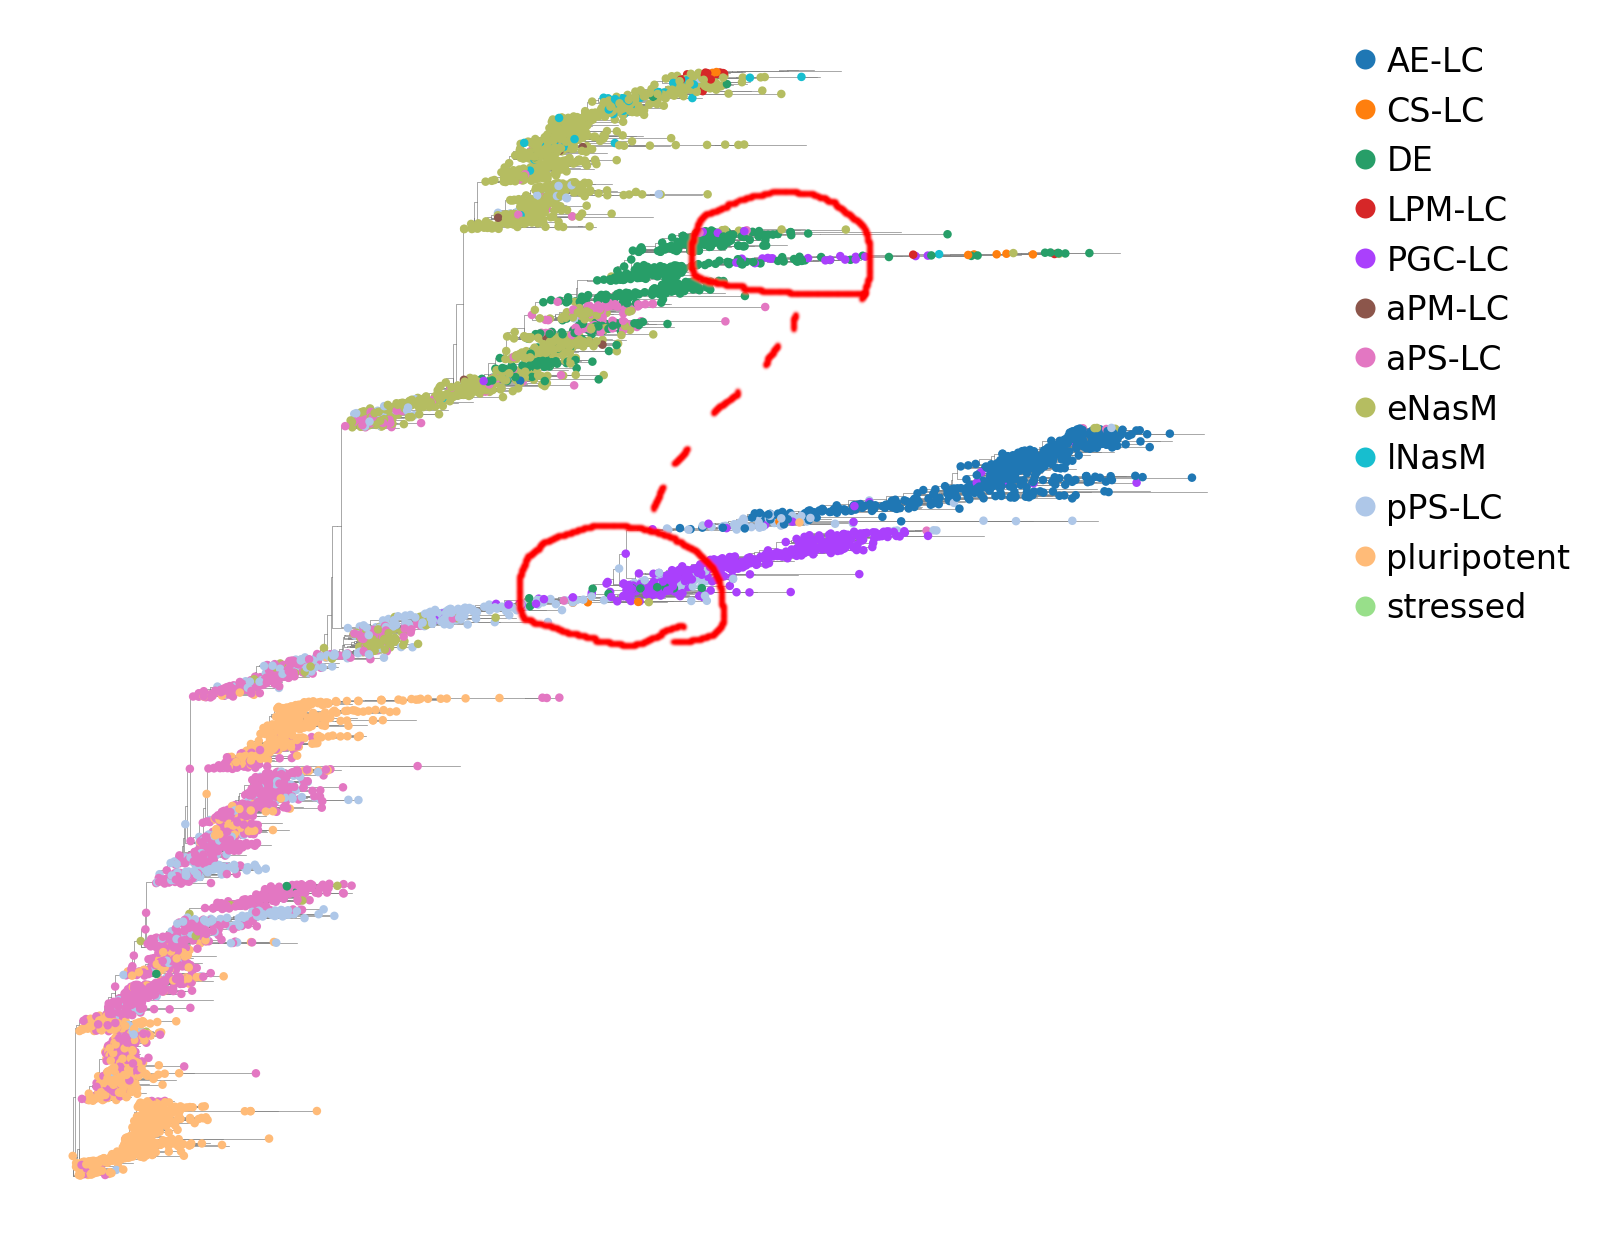

In [21]:
# looks same as previous dendrogram
from IPython.display import Image

Image("bonsai-tree-annotated.png")

### Contact maps by levels with nodes ordered by distance to root

In [22]:
# first try to reproduce previous contact maps on leaves
# compute ordering
ordering_node_ids = bl.convergence.compute_node_ordering(
    node_data_lookup=node_data_lookup,
    level=0,
    sort_by_identity_first=True,
    ascending=True,
)
pprint(ordering_node_ids[:5])
print(f"{'─' * 88}")
# similar as the notebook 2d-human-gastruloid-pgc-endo-convergence.ipynb
gas_tree_distances, gas_tree_distances_node_ids = (
    bl.convergence.get_pdists_on_tree_by_level(
        tree=scData.tree,
        node_data_lookup=node_data_lookup,
        dist_type="bonsai_t",
        level=0,
    )
)
pprint(gas_tree_distances_node_ids[:5])
pprint(gas_tree_distances[:5])
print(f"{'─' * 88}")
gas_euclidean_distances_tree, gas_euclidean_distances_tree_node_ids = (
    bl.convergence.get_pdists_on_tree_by_level(
        tree=scData.tree,
        node_data_lookup=node_data_lookup,
        dist_type="euclidean",
        level=0,
    )
)
pprint(gas_euclidean_distances_tree_node_ids[:5])
pprint(gas_euclidean_distances_tree[:5])
print(f"{'─' * 88}")
gas_euclidean_distances_straight, gas_euclidean_distances_straight_node_ids = (
    bl.convergence.get_pdists_embedding_by_level(
        node_data_lookup=node_data_lookup,
        level=0,
    )
)
pprint(gas_euclidean_distances_tree_node_ids[:5])
pprint(gas_euclidean_distances_tree[:5])

['AGACAGGAGCCTATTG-1_48h',
 'GCCATGGCAAGTTTGC-1_48h',
 'AAGGAATAGAGCAGTC-1_48h',
 'GCACGGTGTTATAGAG-1_48h',
 'GGGACAATCAGTCCGG-1_48h']
────────────────────────────────────────────────────────────────────────────────────────
['GTGCAGCCAGTTAGGG-1_48h',
 'GTCGAATCAAGGAGTC-1_48h',
 'GTGCTGGGTACCCAGC-1_48h',
 'TCCTCCCGTTACCTTT-1_48h',
 'GAAGAATAGCCTGCCA-1_48h']
array([0.07862256, 0.05946231, 0.16541475, 0.15264045, 0.2181817 ])
────────────────────────────────────────────────────────────────────────────────────────
['GTGCAGCCAGTTAGGG-1_48h',
 'GTCGAATCAAGGAGTC-1_48h',
 'GTGCTGGGTACCCAGC-1_48h',
 'TCCTCCCGTTACCTTT-1_48h',
 'GAAGAATAGCCTGCCA-1_48h']
array([0.01857299, 0.00829623, 0.06847081, 0.05460337, 0.07401343])
────────────────────────────────────────────────────────────────────────────────────────
['GTGCAGCCAGTTAGGG-1_48h',
 'GTCGAATCAAGGAGTC-1_48h',
 'GTGCTGGGTACCCAGC-1_48h',
 'TCCTCCCGTTACCTTT-1_48h',
 'GAAGAATAGCCTGCCA-1_48h']
array([0.01857299, 0.00829623, 0.06847081, 0.05460337, 0.

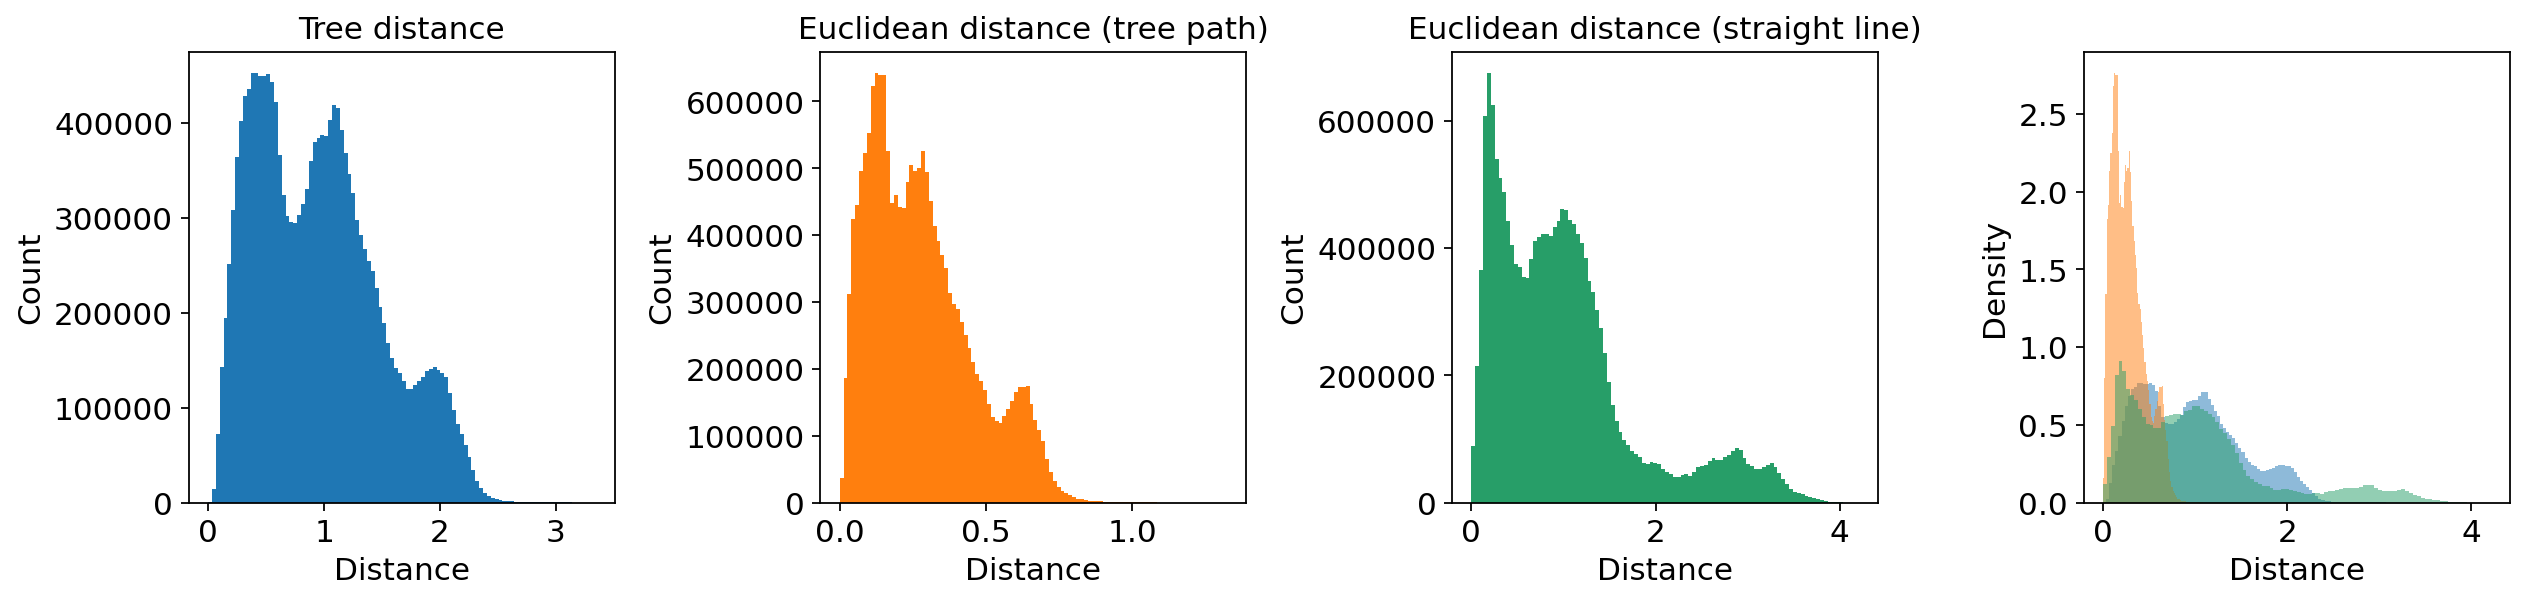

In [23]:
# check distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(gas_tree_distances, bins=100, color="C0")
axes[0].set_title("Tree distance")
axes[1].hist(
    gas_euclidean_distances_tree,
    bins=100,
    color="C1",
)
axes[1].set_title("Euclidean distance (tree path)")
axes[2].hist(
    gas_euclidean_distances_straight,
    bins=100,
    color="C2",
)
axes[2].set_title("Euclidean distance (straight line)")
for i, dists in enumerate(
    [gas_tree_distances, gas_euclidean_distances_tree, gas_euclidean_distances_straight]
):
    axes[3].hist(
        dists,
        bins=100,
        color=f"C{i}",
        alpha=0.5,
        density=True,
    )

for i, ax in enumerate(axes):
    ax.set_xlabel("Distance")
    ax.set_ylabel("Count") if i < 3 else ax.set_ylabel("Density")
    ax.grid(False)

plt.tight_layout()
plt.show()
plt.close()
# same plots reproduced

In [24]:
# helper function to do quantile based matching
def quantile_matching(
    dists: list[np.ndarray], quantiles: list[float]
) -> list[np.ndarray]:
    lo_pct, up_pct = quantiles
    dists_quantiles = []
    for dist in dists:
        dists_quantiles.append(np.quantile(dist, [lo_pct, up_pct]))
    dists_match = [dists[0]]
    for i, dist in enumerate(dists[1:]):
        dists_match.append(
            np.maximum(
                (dist - dists_quantiles[i + 1][0])
                / (dists_quantiles[i + 1][1] - dists_quantiles[i + 1][0])
                * (dists_quantiles[0][1] - dists_quantiles[0][0])
                + dists_quantiles[0][0],
                0,
            )
        )
    return dists_match


(
    gas_tree_distances,
    gas_euclidean_distances_tree_match,
    gas_euclidean_distances_straight_match,
) = quantile_matching(
    [
        gas_tree_distances,
        gas_euclidean_distances_tree,
        gas_euclidean_distances_straight,
    ],
    [0.05, 0.95],
)

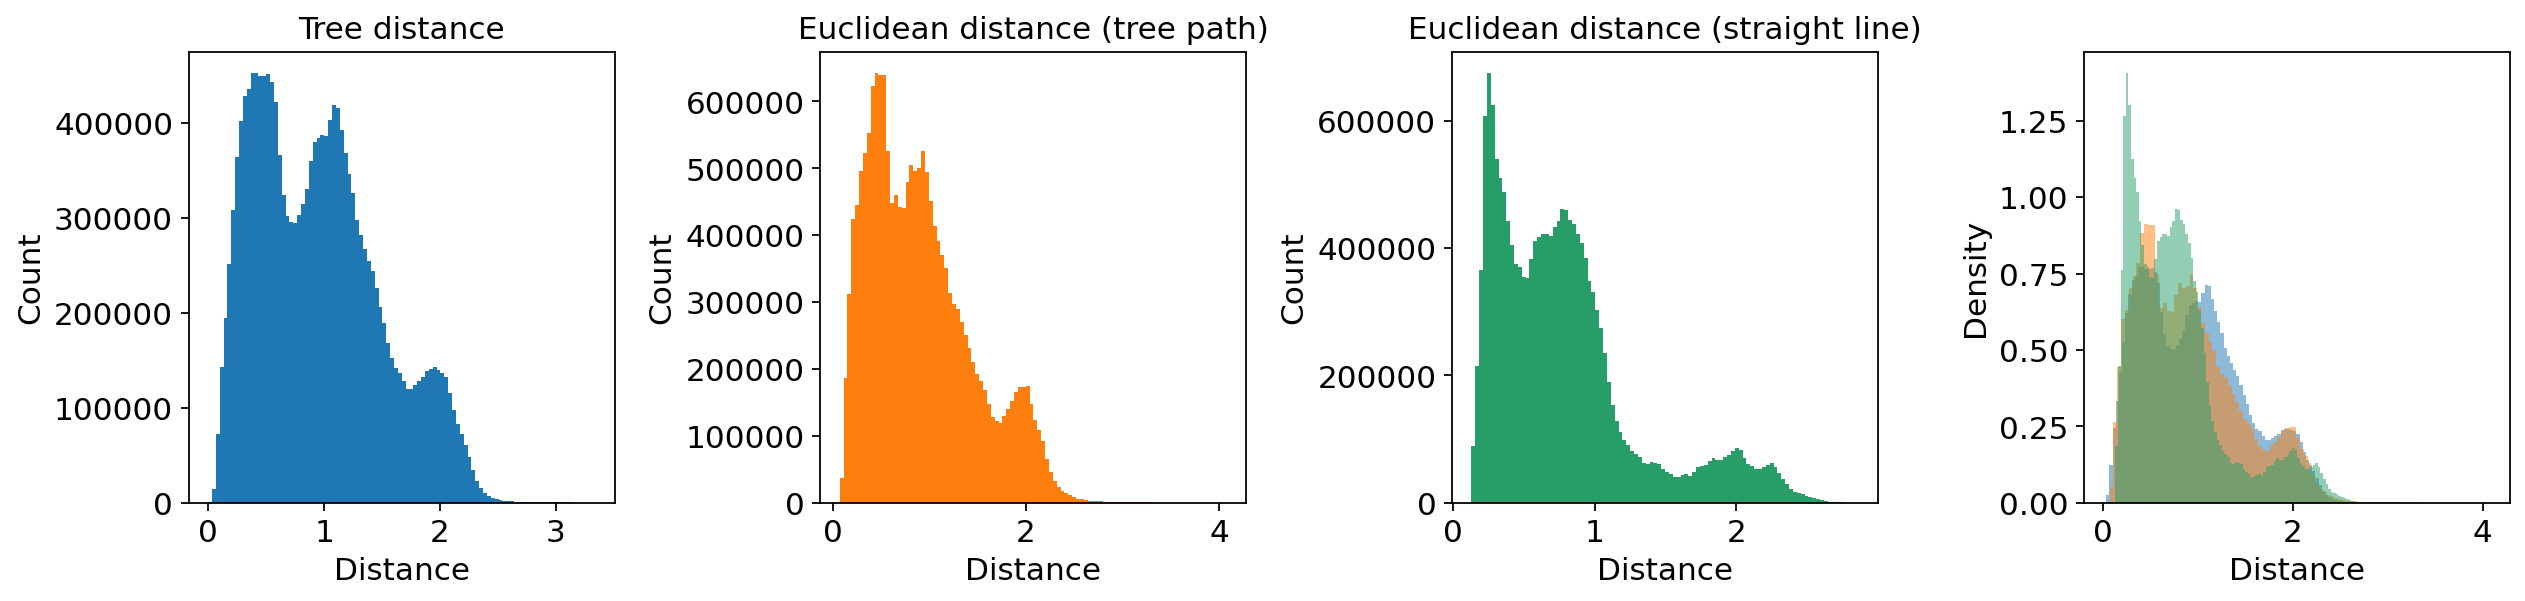

In [25]:
# check distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(gas_tree_distances, bins=100, color="C0")
axes[0].set_title("Tree distance")
axes[1].hist(
    gas_euclidean_distances_tree_match,
    bins=100,
    color="C1",
)
axes[1].set_title("Euclidean distance (tree path)")
axes[2].hist(
    gas_euclidean_distances_straight_match,
    bins=100,
    color="C2",
)
axes[2].set_title("Euclidean distance (straight line)")
for i, dists in enumerate(
    [
        gas_tree_distances,
        gas_euclidean_distances_tree_match,
        gas_euclidean_distances_straight_match,
    ]
):
    axes[3].hist(
        dists,
        bins=100,
        color=f"C{i}",
        alpha=0.5,
        density=True,
    )

for i, ax in enumerate(axes):
    ax.set_xlabel("Distance")
    ax.set_ylabel("Count") if i < 3 else ax.set_ylabel("Density")
    ax.grid(False)

plt.tight_layout()
plt.show()
plt.close()

In [26]:
# order matries
def arg_order(target_ordering_node_ids, source_ordering_node_ids):
    source_ind = {node_id: i for i, node_id in enumerate(source_ordering_node_ids)}
    return [source_ind[node_id] for node_id in target_ordering_node_ids]


sort_idx = arg_order(ordering_node_ids, gas_tree_distances_node_ids)
gas_dist_matrix_tree_t_ordered = squareform(gas_tree_distances)[sort_idx, :][
    :, sort_idx
]
sort_idx = arg_order(ordering_node_ids, gas_euclidean_distances_tree_node_ids)
gas_dist_matrix_tree_e_ordered = squareform(gas_euclidean_distances_tree_match)[
    sort_idx, :
][:, sort_idx]
sort_idx = arg_order(ordering_node_ids, gas_euclidean_distances_straight_node_ids)
gas_dist_matrix_straight_ordered = squareform(gas_euclidean_distances_straight_match)[
    sort_idx, :
][:, sort_idx]

In [27]:
# cell type identity matrix
gas_window_size = 20
gas_cell_types = pd.Categorical(adata.obs["leiden_sub"]).categories
gas_colors = adata.uns["leiden_sub_colors"]
gas_cell_composition_matrix = np.zeros((len(gas_cell_types) + 1, len(gas_cell_ids)))
for i, cell_type in enumerate(gas_cell_types):
    res = np.convolve(
        adata.obs.loc[ordering_node_ids, "leiden_sub"] == cell_type,
        np.ones(gas_window_size),
        mode="valid",
    )
    margin = int(np.ceil((gas_cell_composition_matrix.shape[1] - res.shape[0]) / 2))
    res = np.pad(res, (margin, margin), mode="constant")
    gas_cell_composition_matrix[i, :] = res[: gas_cell_composition_matrix.shape[1]]
gas_cell_composition_matrix[-1, :] = 1
gas_cell_composition_matrix = gas_cell_composition_matrix / np.sum(
    gas_cell_composition_matrix, axis=0
)

In [28]:
# reproduce heatmaps
FONTSIZE = 15
figure_dir = pathlib.Path("notebooks/figures/contact_maps")
if pathlib.Path("data").exists() and not pathlib.Path("notebooks").exists():
    figure_dir = pathlib.Path("figures/contact_maps")
figure_dir.mkdir(parents=True, exist_ok=True)

heatmaps = [
    {
        "mat": gas_dist_matrix_tree_t_ordered,
        "title": "Bonsai tree distance (t)",
        "cmap": "viridis",
        "vmin_pct": 1,
        "vmax_pct": 99,
        "vmin": None,
        "vmax": None,
        "filename": "level0_bonsai_tree_distance_t.png",
    },
    {
        "mat": gas_dist_matrix_tree_e_ordered,
        "title": "Bonsai tree distance (euclidean)",
        "cmap": "viridis",
        "vmin_pct": 1,
        "vmax_pct": 99,
        "vmin": None,
        "vmax": None,
        "filename": "level0_bonsai_tree_distance_euclidean.png",
    },
    {
        "mat": gas_dist_matrix_straight_ordered,
        "title": "Embedding euclidean distance",
        "cmap": "viridis",
        "vmin_pct": 25,
        "vmax_pct": 99,
        "vmin": None,
        "vmax": None,
        "filename": "level0_embedding_euclidean_distance.png",
    },
    {
        "mat": gas_dist_matrix_tree_e_ordered - gas_dist_matrix_straight_ordered,
        "title": "Bonsai tree distance (euclidean) - Embedding euclidean distance",
        "cmap": "cividis",
        "vmin_pct": 1,
        "vmax_pct": 99,
        "vmin": 0.0,
        "vmax": 1.5,
        "filename": "level0_tree_e_minus_embedding_euclidean.png",
    },
]

for i, heatmap in enumerate(heatmaps):
    # make sure matrix is symmetric
    plot_mat = (heatmap["mat"] + heatmap["mat"].T) / 2

    # simple linear percentile color scaling
    vmin_pct = heatmap["vmin_pct"]
    vmax_pct = heatmap["vmax_pct"]
    if vmin_pct is None:
        vmin_pct = 0
    if vmax_pct is None:
        vmax_pct = 100
    vmin = (
        np.percentile(plot_mat, vmin_pct)
        if heatmap["vmin"] is None
        else heatmap["vmin"]
    )
    vmax = (
        np.percentile(plot_mat, vmax_pct)
        if heatmap["vmax"] is None
        else heatmap["vmax"]
    )
    norm = Normalize(vmin=vmin, vmax=vmax)

    g = sns.clustermap(
        plot_mat,
        cmap=heatmap["cmap"],
        cbar=True,
        square=False,
        xticklabels=False,
        yticklabels=False,
        row_cluster=False,
        col_cluster=False,
        figsize=(10, 10),
        rasterized=True,
        norm=norm,
    )
    ax_hm = g.ax_heatmap
    ax_hm.set_aspect("equal")
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)
    g.cax.set_visible(False)

    ax_hm.set_position([0.1, 0.08, 0.78, 0.78])
    pos = ax_hm.get_position()

    n = plot_mat.shape[1]
    n_rows = plot_mat.shape[0]
    x = np.arange(n)
    y = np.arange(n_rows)

    tick_x = np.arange(0, n, 100)
    tick_x_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_x]
    ax_hm.set_xticks(tick_x)
    ax_hm.set_xticklabels(tick_x_labels, fontsize=FONTSIZE)
    ax_hm.tick_params(axis="x", which="major", length=3, direction="out")
    ax_hm.grid(False)

    tick_y = np.arange(0, n_rows, 100)
    tick_y_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_y]
    ax_hm.set_yticks(tick_y)
    ax_hm.set_yticklabels(tick_y_labels, fontsize=FONTSIZE)
    ax_hm.tick_params(axis="y", which="major", length=3, direction="out")
    ax_hm.set_xlabel("cells", fontsize=FONTSIZE)
    ax_hm.set_ylabel("cells", fontsize=FONTSIZE)

    ax_top = g.fig.add_axes([pos.x0, pos.y1 + 0.01, pos.width, 0.05])
    ax_top.stackplot(
        x, gas_cell_composition_matrix[:-1, :], labels=gas_cell_types, colors=gas_colors
    )
    ax_top.set_xlim(ax_hm.get_xlim())
    ax_top.axis("off")
    ax_top.text(
        1.01,
        0.5,
        "cell identity",
        transform=ax_top.transAxes,
        ha="left",
        va="center",
        rotation=0,
        fontsize=FONTSIZE,
        clip_on=False,
    )

    ax_left = g.fig.add_axes([pos.x0 - 0.06, pos.y0, 0.05, pos.height])
    cumulative = np.cumsum(gas_cell_composition_matrix[:-1, :], axis=0)
    prev = np.zeros(n_rows)
    for k in range(cumulative.shape[0]):
        ax_left.fill_betweenx(y, prev, cumulative[k], color=gas_colors[k])
        prev = cumulative[k]
    ax_left.set_xlim(1, 0)
    ax_left.set_ylim(ax_hm.get_ylim())
    ax_left.axis("off")

    ax_top.set_title(heatmap["title"], fontsize=FONTSIZE * 1.5)

    mappable = ScalarMappable(norm=norm, cmap=heatmap["cmap"])
    mappable.set_array([])
    cax = g.fig.add_axes([pos.x0 - 0.03, 1.01, 0.1, 0.018])
    cb = g.fig.colorbar(mappable, cax=cax, orientation="horizontal")
    cb.set_label("value", fontsize=FONTSIZE, labelpad=4)
    if vmin < 0 < vmax:
        cb.set_ticks([vmin, 0, vmax], labels=[f"{vmin:.1f}", "0", f"{vmax:.1f}"])
    else:
        cb.set_ticks([vmin, vmax], labels=[f"{vmin:.1f}", f"{vmax:.1f}"])
    cb.ax.tick_params(labelsize=FONTSIZE)

    g.fig.savefig(figure_dir / heatmap["filename"], dpi=300, bbox_inches="tight")
    plt.close()
    gc.collect()

#### Level 0 contact map

<table>
  <tr>
    <td><img src="figures/contact_maps/level0_bonsai_tree_distance_t.png" alt="Bonsai tree distance (t)" width="50%"></td>
    <td><img src="figures/contact_maps/level0_bonsai_tree_distance_euclidean.png" alt="Bonsai tree distance (euclidean)" width="50%"></td>
  </tr>
  <tr>
    <td><img src="figures/contact_maps/level0_embedding_euclidean_distance.png" alt="Embedding euclidean distance" width="50%"></td>
    <td><img src="figures/contact_maps/level0_tree_e_minus_embedding_euclidean.png" alt="Tree euclidean minus embedding euclidean" width="50%"></td>
  </tr>
</table>


The new module has reproduced the previous results, now move on to repeat same pipeline for other tree levels

#### Convergence matrix (Bonsai tree distance (euclidean) - Embedding euclidean distance) at different tree levels

In [45]:
# convergence matrices across sampled topological levels
sample_levels = list(range(0, 64, 4))
figure_dir = pathlib.Path("notebooks/figures/contact_maps")
if pathlib.Path("data").exists() and not pathlib.Path("notebooks").exists():
    figure_dir = pathlib.Path("figures/contact_maps")
figure_dir.mkdir(parents=True, exist_ok=True)

node_data_lookup_leiden = bl.convergence.compute_tree_node_level_and_label(
    tree=scData.tree,
    node_level_type="topological",
    label_lookup_leaves=adata.obs["leiden_sub"].to_dict(),
)

level_difference_mats = []
level_ordering_node_ids_list = []
for level in sample_levels:
    level_ordering_node_ids = bl.convergence.compute_node_ordering(
        node_data_lookup=node_data_lookup,
        level=level,
        sort_by_identity_first=True,
        ascending=True,
    )
    level_ordering_node_ids_list.append(level_ordering_node_ids)
    if len(level_ordering_node_ids) < 2:
        level_difference_mats.append(None)
        continue

    level_tree_distances, level_tree_node_ids = (
        bl.convergence.get_pdists_on_tree_by_level(
            tree=scData.tree,
            node_data_lookup=node_data_lookup,
            dist_type="bonsai_t",
            level=level,
        )
    )
    level_tree_euclidean_distances, level_tree_euclidean_node_ids = (
        bl.convergence.get_pdists_on_tree_by_level(
            tree=scData.tree,
            node_data_lookup=node_data_lookup,
            dist_type="euclidean",
            level=level,
        )
    )
    level_straight_distances, level_straight_node_ids = (
        bl.convergence.get_pdists_embedding_by_level(
            node_data_lookup=node_data_lookup,
            level=level,
        )
    )

    _, level_tree_euclidean_distances_match, level_straight_distances_match = (
        quantile_matching(
            [
                level_tree_distances,
                level_tree_euclidean_distances,
                level_straight_distances,
            ],
            [0.05, 0.95],
        )
    )

    sort_idx = arg_order(level_ordering_node_ids, level_tree_euclidean_node_ids)
    level_tree_euclidean_mat = squareform(level_tree_euclidean_distances_match)[
        sort_idx, :
    ][:, sort_idx]
    sort_idx = arg_order(level_ordering_node_ids, level_straight_node_ids)
    level_straight_mat = squareform(level_straight_distances_match)[sort_idx, :][
        :, sort_idx
    ]
    level_difference_mats.append(level_tree_euclidean_mat - level_straight_mat)

FONTSIZE = 22
norm = Normalize(vmin=0.0, vmax=1.5)

gas_window_fraction = 15 / len(gas_cell_ids)
gas_cell_types = pd.Categorical(adata.obs["leiden_sub"]).categories
gas_colors = adata.uns["leiden_sub_colors"]


def get_level_identity_matrix(node_ids, window_size=None):
    level_identity_matrix = np.zeros((len(gas_cell_types) + 1, len(node_ids)))
    level_window_size = (
        int(np.round(gas_window_fraction * len(node_ids)))
        if window_size is None
        else window_size
    )
    for i, cell_type in enumerate(gas_cell_types):
        cell_type_vec = np.array(
            [
                node_data_lookup_leiden[node_id].identity.get(cell_type, 0)
                if node_data_lookup_leiden[node_id].identity is not None
                else 0
                for node_id in node_ids
            ]
        )
        if level_window_size < 1:
            res = cell_type_vec
        else:
            res = np.convolve(
                cell_type_vec,
                np.ones(level_window_size),
                mode="valid",
            )
            margin = int(np.ceil((level_identity_matrix.shape[1] - res.shape[0]) / 2))
            res = np.pad(res, (margin, margin), mode="constant")
        level_identity_matrix[i, :] = res[: level_identity_matrix.shape[1]]
    level_identity_matrix[-1, :] = 1
    level_identity_matrix = level_identity_matrix / np.sum(
        level_identity_matrix, axis=0
    )
    return level_identity_matrix


fig = plt.figure(figsize=(18, 20), constrained_layout=True)
grid = fig.add_gridspec(4, 4)
image = None
heatmap_axes = []
for i, (level, mat, node_ids) in enumerate(
    zip(sample_levels, level_difference_mats, level_ordering_node_ids_list)
):
    row = i // 4
    col = i % 4
    ax_heatmap = fig.add_subplot(grid[row, col])
    heatmap_axes.append(ax_heatmap)

    if mat is None:
        ax_heatmap.text(0.5, 0.5, f"level {level}\n<2 nodes", ha="center", va="center")
        ax_heatmap.axis("off")
        continue

    x = np.arange(len(node_ids) + 1) - 0.5
    if i > 3:
        identity_matrix = get_level_identity_matrix(node_ids, window_size=0)
    else:
        identity_matrix = get_level_identity_matrix(node_ids)
    plot_mat = (mat + mat.T) / 2
    image = ax_heatmap.imshow(
        plot_mat, cmap="cividis", norm=norm, interpolation="nearest"
    )
    ax_heatmap.set_xticks([])
    ax_heatmap.set_yticks([])
    ax_heatmap.set_aspect("equal")

    identity_matrix_plot = np.pad(
        identity_matrix[:-1, :], ((0, 0), (0, 1)), mode="edge"
    )
    identity_strip_size = 0.08
    ax_identity = ax_heatmap.inset_axes([0, 1.04, 1, identity_strip_size])
    ax_identity.stackplot(x, identity_matrix_plot, colors=gas_colors, step="post")
    ax_identity.set_xlim(ax_heatmap.get_xlim())
    ax_identity.axis("off")
    ax_identity.set_title(f"level {level} (n={plot_mat.shape[0]})", fontsize=FONTSIZE)

    y = np.arange(plot_mat.shape[0] + 1) - 0.5
    cumulative = np.cumsum(identity_matrix_plot, axis=0)
    prev = np.zeros(plot_mat.shape[0] + 1)
    ax_left = ax_heatmap.inset_axes([-0.12, 0, identity_strip_size, 1])
    for k in range(cumulative.shape[0]):
        ax_left.fill_betweenx(y, prev, cumulative[k], color=gas_colors[k], step="post")
        prev = cumulative[k]
    ax_left.set_xlim(1, 0)
    ax_left.set_ylim(ax_heatmap.get_ylim())
    ax_left.axis("off")

if image is not None:
    cbar = fig.colorbar(image, ax=heatmap_axes, shrink=0.75)
    cbar.set_label(
        "Bonsai tree distance (euclidean) - Embedding euclidean distance",
        fontsize=FONTSIZE,
    )
    cbar.ax.tick_params(labelsize=FONTSIZE)

fig.savefig(
    figure_dir / "sampled_levels_tree_e_minus_embedding_euclidean.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()
gc.collect()

compute depth-first ordering of nodes
root node internal_1880
compute node level and label


11069it [00:00, 273645.83it/s]


130556

#### Convergence matrices across sampled topological levels
<img src="figures/contact_maps/sampled_levels_tree_e_minus_embedding_euclidean.png" alt="Convergence matrices across sampled topological levels" width="75%">

### Contact maps by levels with nodes ordered by dendrogram y-position

In [23]:
# reset ordering value
node_data_lookup = bl.convergence.compute_tree_node_level_and_label(
    tree=scData.tree,
    node_level_type="topological",
    label_lookup_leaves=adata.obs["bonsai_cluster"].to_dict(),
)
# root node
print(node_data_lookup["internal_1880"])
# a real cell (a leaf)
print(node_data_lookup["TTTGTTGTCCATTTCA-1_48h"])

compute depth-first ordering of nodes
root node internal_1880
compute node level and label


11069it [00:00, 286933.81it/s]

┌───────────────────┬──────────────────────────────────────────────┐
│ attribute         │ value                                        │
├───────────────────┼──────────────────────────────────────────────┤
│ tree_node         │ TreeNode(nodeId='internal_1880')             │
│ topological_level │ 195                                          │
│ geometric_level   │ None                                         │
│ identity          │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves          │ 5927                                         │
│ ordering_value    │ None                                         │
│ dendrogram_coords │ None                                         │
│ other_props       │ None                                         │
└───────────────────┴──────────────────────────────────────────────┘
┌───────────────────┬───────────────────────────────────────────┐
│ attribute         │ value                                     │
├───────────────────┼───────────────────

In [24]:
# compute dendrogram first
bl.convergence.compute_bonsai_tree_dendrogram(
    tree=scData.tree,
    node_data_lookup=node_data_lookup,
    ladderize_by_annotated_leaves_only=True,
)
# root node (should have dendrogram coordinates now)
print(node_data_lookup["internal_1880"])
# a real cell (should have dendrogram coordinates now)
print(node_data_lookup["TTTGTTGTCCATTTCA-1_48h"])

┌───────────────────┬──────────────────────────────────────────────┐
│ attribute         │ value                                        │
├───────────────────┼──────────────────────────────────────────────┤
│ tree_node         │ TreeNode(nodeId='internal_1880')             │
│ topological_level │ 195                                          │
│ geometric_level   │ None                                         │
│ identity          │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves          │ 5927                                         │
│ ordering_value    │ None                                         │
│ dendrogram_coords │ (-0.95, -0.9159482420614774)                 │
│ other_props       │ None                                         │
└───────────────────┴──────────────────────────────────────────────┘
┌───────────────────┬───────────────────────────────────────────┐
│ attribute         │ value                                     │
├───────────────────┼───────────────────

In [25]:
bl.convergence.compute_node_ordering_value(
    tree=scData.tree, node_data_lookup=node_data_lookup, metric="dendrogram"
)
# root node (should have ordering value being the same as the dendrogram y-position)
print(node_data_lookup["internal_1880"])
# a real cell (should have ordering value being the same as the dendrogram y-position)
print(node_data_lookup["TTTGTTGTCCATTTCA-1_48h"])
ordering_node_ids = bl.convergence.compute_node_ordering(
    node_data_lookup=node_data_lookup,
    level=0,
    sort_by_identity_first=True,
    ascending=True,
)
pprint(ordering_node_ids[:5])

compute node ordering using metric dendrogram
┌───────────────────┬──────────────────────────────────────────────┐
│ attribute         │ value                                        │
├───────────────────┼──────────────────────────────────────────────┤
│ tree_node         │ TreeNode(nodeId='internal_1880')             │
│ topological_level │ 195                                          │
│ geometric_level   │ None                                         │
│ identity          │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves          │ 5927                                         │
│ ordering_value    │ -0.9159482420614774                          │
│ dendrogram_coords │ (-0.95, -0.9159482420614774)                 │
│ other_props       │ None                                         │
└───────────────────┴──────────────────────────────────────────────┘
┌───────────────────┬───────────────────────────────────────────┐
│ attribute         │ value                                 

In [28]:
# recompute distances
gas_tree_distances, gas_tree_distances_node_ids = (
    bl.convergence.get_pdists_on_tree_by_level(
        tree=scData.tree,
        node_data_lookup=node_data_lookup,
        dist_type="bonsai_t",
        level=0,
    )
)
pprint(gas_tree_distances_node_ids[:5])
pprint(gas_tree_distances[:5])
print(f"{'─' * 88}")
gas_euclidean_distances_tree, gas_euclidean_distances_tree_node_ids = (
    bl.convergence.get_pdists_on_tree_by_level(
        tree=scData.tree,
        node_data_lookup=node_data_lookup,
        dist_type="euclidean",
        level=0,
    )
)
pprint(gas_euclidean_distances_tree_node_ids[:5])
pprint(gas_euclidean_distances_tree[:5])
print(f"{'─' * 88}")
gas_euclidean_distances_straight, gas_euclidean_distances_straight_node_ids = (
    bl.convergence.get_pdists_embedding_by_level(
        node_data_lookup=node_data_lookup,
        level=0,
    )
)
pprint(gas_euclidean_distances_tree_node_ids[:5])
pprint(gas_euclidean_distances_tree[:5])


# quantile matching
# helper function to do quantile based matching
def quantile_matching(
    dists: list[np.ndarray], quantiles: list[float]
) -> list[np.ndarray]:
    lo_pct, up_pct = quantiles
    dists_quantiles = []
    for dist in dists:
        dists_quantiles.append(np.quantile(dist, [lo_pct, up_pct]))
    dists_match = [dists[0]]
    for i, dist in enumerate(dists[1:]):
        dists_match.append(
            np.maximum(
                (dist - dists_quantiles[i + 1][0])
                / (dists_quantiles[i + 1][1] - dists_quantiles[i + 1][0])
                * (dists_quantiles[0][1] - dists_quantiles[0][0])
                + dists_quantiles[0][0],
                0,
            )
        )
    return dists_match


(
    gas_tree_distances,
    gas_euclidean_distances_tree_match,
    gas_euclidean_distances_straight_match,
) = quantile_matching(
    [
        gas_tree_distances,
        gas_euclidean_distances_tree,
        gas_euclidean_distances_straight,
    ],
    [0.05, 0.95],
)


# order matrices
def arg_order(target_ordering_node_ids, source_ordering_node_ids):
    source_ind = {node_id: i for i, node_id in enumerate(source_ordering_node_ids)}
    return [source_ind[node_id] for node_id in target_ordering_node_ids]


sort_idx = arg_order(ordering_node_ids, gas_tree_distances_node_ids)
gas_dist_matrix_tree_t_ordered = squareform(gas_tree_distances)[sort_idx, :][
    :, sort_idx
]
sort_idx = arg_order(ordering_node_ids, gas_euclidean_distances_tree_node_ids)
gas_dist_matrix_tree_e_ordered = squareform(gas_euclidean_distances_tree_match)[
    sort_idx, :
][:, sort_idx]
sort_idx = arg_order(ordering_node_ids, gas_euclidean_distances_straight_node_ids)
gas_dist_matrix_straight_ordered = squareform(gas_euclidean_distances_straight_match)[
    sort_idx, :
][:, sort_idx]
# cell type identity matrix
gas_window_size = 20
gas_cell_types = pd.Categorical(adata.obs["leiden_sub"]).categories
gas_colors = adata.uns["leiden_sub_colors"]
gas_cell_composition_matrix = np.zeros((len(gas_cell_types) + 1, len(gas_cell_ids)))
for i, cell_type in enumerate(gas_cell_types):
    res = np.convolve(
        adata.obs.loc[ordering_node_ids, "leiden_sub"] == cell_type,
        np.ones(gas_window_size),
        mode="valid",
    )
    margin = int(np.ceil((gas_cell_composition_matrix.shape[1] - res.shape[0]) / 2))
    res = np.pad(res, (margin, margin), mode="constant")
    gas_cell_composition_matrix[i, :] = res[: gas_cell_composition_matrix.shape[1]]
gas_cell_composition_matrix[-1, :] = 1
gas_cell_composition_matrix = gas_cell_composition_matrix / np.sum(
    gas_cell_composition_matrix, axis=0
)

['GTGCAGCCAGTTAGGG-1_48h',
 'GTCGAATCAAGGAGTC-1_48h',
 'GTGCTGGGTACCCAGC-1_48h',
 'TCCTCCCGTTACCTTT-1_48h',
 'GAAGAATAGCCTGCCA-1_48h']
array([0.07862256, 0.05946231, 0.16541475, 0.15264045, 0.2181817 ])
────────────────────────────────────────────────────────────────────────────────────────
['GTGCAGCCAGTTAGGG-1_48h',
 'GTCGAATCAAGGAGTC-1_48h',
 'GTGCTGGGTACCCAGC-1_48h',
 'TCCTCCCGTTACCTTT-1_48h',
 'GAAGAATAGCCTGCCA-1_48h']
array([0.01857299, 0.00829623, 0.06847081, 0.05460337, 0.07401343])
────────────────────────────────────────────────────────────────────────────────────────
['GTGCAGCCAGTTAGGG-1_48h',
 'GTCGAATCAAGGAGTC-1_48h',
 'GTGCTGGGTACCCAGC-1_48h',
 'TCCTCCCGTTACCTTT-1_48h',
 'GAAGAATAGCCTGCCA-1_48h']
array([0.01857299, 0.00829623, 0.06847081, 0.05460337, 0.07401343])


In [29]:
FONTSIZE = 15
figure_dir = pathlib.Path("notebooks/figures/contact_maps")
if pathlib.Path("data").exists() and not pathlib.Path("notebooks").exists():
    figure_dir = pathlib.Path("figures/contact_maps")
figure_dir.mkdir(parents=True, exist_ok=True)

heatmaps = [
    {
        "mat": gas_dist_matrix_tree_t_ordered,
        "title": "Bonsai tree distance (t)",
        "cmap": "viridis",
        "vmin_pct": 1,
        "vmax_pct": 99,
        "vmin": None,
        "vmax": None,
        "filename": "level0_bonsai_tree_distance_t_dendrogram_order.png",
    },
    {
        "mat": gas_dist_matrix_tree_e_ordered,
        "title": "Bonsai tree distance (euclidean)",
        "cmap": "viridis",
        "vmin_pct": 1,
        "vmax_pct": 99,
        "vmin": None,
        "vmax": None,
        "filename": "level0_bonsai_tree_distance_euclidean_dendrogram_order.png",
    },
    {
        "mat": gas_dist_matrix_straight_ordered,
        "title": "Embedding euclidean distance",
        "cmap": "viridis",
        "vmin_pct": 25,
        "vmax_pct": 99,
        "vmin": None,
        "vmax": None,
        "filename": "level0_embedding_euclidean_distance_dendrogram_order.png",
    },
    {
        "mat": gas_dist_matrix_tree_e_ordered - gas_dist_matrix_straight_ordered,
        "title": "Bonsai tree distance (euclidean) - Embedding euclidean distance",
        "cmap": "cividis",
        "vmin_pct": 1,
        "vmax_pct": 99,
        "vmin": 0.0,
        "vmax": 1.5,
        "filename": "level0_tree_e_minus_embedding_euclidean_dendrogram_order.png",
    },
]

for i, heatmap in enumerate(heatmaps):
    # make sure matrix is symmetric
    plot_mat = (heatmap["mat"] + heatmap["mat"].T) / 2

    # simple linear percentile color scaling
    vmin_pct = heatmap["vmin_pct"]
    vmax_pct = heatmap["vmax_pct"]
    if vmin_pct is None:
        vmin_pct = 0
    if vmax_pct is None:
        vmax_pct = 100
    vmin = (
        np.percentile(plot_mat, vmin_pct)
        if heatmap["vmin"] is None
        else heatmap["vmin"]
    )
    vmax = (
        np.percentile(plot_mat, vmax_pct)
        if heatmap["vmax"] is None
        else heatmap["vmax"]
    )
    norm = Normalize(vmin=vmin, vmax=vmax)

    g = sns.clustermap(
        plot_mat,
        cmap=heatmap["cmap"],
        cbar=True,
        square=False,
        xticklabels=False,
        yticklabels=False,
        row_cluster=False,
        col_cluster=False,
        figsize=(10, 10),
        rasterized=True,
        norm=norm,
    )
    ax_hm = g.ax_heatmap
    ax_hm.set_aspect("equal")
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)
    g.cax.set_visible(False)

    ax_hm.set_position([0.1, 0.08, 0.78, 0.78])
    pos = ax_hm.get_position()

    n = plot_mat.shape[1]
    n_rows = plot_mat.shape[0]
    x = np.arange(n)
    y = np.arange(n_rows)

    tick_x = np.arange(0, n, 100)
    tick_x_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_x]
    ax_hm.set_xticks(tick_x)
    ax_hm.set_xticklabels(tick_x_labels, fontsize=FONTSIZE)
    ax_hm.tick_params(axis="x", which="major", length=3, direction="out")
    ax_hm.grid(False)

    tick_y = np.arange(0, n_rows, 100)
    tick_y_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_y]
    ax_hm.set_yticks(tick_y)
    ax_hm.set_yticklabels(tick_y_labels, fontsize=FONTSIZE)
    ax_hm.tick_params(axis="y", which="major", length=3, direction="out")
    ax_hm.set_xlabel("cells", fontsize=FONTSIZE)
    ax_hm.set_ylabel("cells", fontsize=FONTSIZE)

    ax_top = g.fig.add_axes([pos.x0, pos.y1 + 0.01, pos.width, 0.05])
    ax_top.stackplot(
        x, gas_cell_composition_matrix[:-1, :], labels=gas_cell_types, colors=gas_colors
    )
    ax_top.set_xlim(ax_hm.get_xlim())
    ax_top.axis("off")
    ax_top.text(
        1.01,
        0.5,
        "cell identity",
        transform=ax_top.transAxes,
        ha="left",
        va="center",
        rotation=0,
        fontsize=FONTSIZE,
        clip_on=False,
    )

    ax_left = g.fig.add_axes([pos.x0 - 0.06, pos.y0, 0.05, pos.height])
    cumulative = np.cumsum(gas_cell_composition_matrix[:-1, :], axis=0)
    prev = np.zeros(n_rows)
    for k in range(cumulative.shape[0]):
        ax_left.fill_betweenx(y, prev, cumulative[k], color=gas_colors[k])
        prev = cumulative[k]
    ax_left.set_xlim(1, 0)
    ax_left.set_ylim(ax_hm.get_ylim())
    ax_left.axis("off")

    ax_top.set_title(heatmap["title"], fontsize=FONTSIZE * 1.5)

    mappable = ScalarMappable(norm=norm, cmap=heatmap["cmap"])
    mappable.set_array([])
    cax = g.fig.add_axes([pos.x0 - 0.03, 1.01, 0.1, 0.018])
    cb = g.fig.colorbar(mappable, cax=cax, orientation="horizontal")
    cb.set_label("value", fontsize=FONTSIZE, labelpad=4)
    if vmin < 0 < vmax:
        cb.set_ticks([vmin, 0, vmax], labels=[f"{vmin:.1f}", "0", f"{vmax:.1f}"])
    else:
        cb.set_ticks([vmin, vmax], labels=[f"{vmin:.1f}", f"{vmax:.1f}"])
    cb.ax.tick_params(labelsize=FONTSIZE)

    g.fig.savefig(figure_dir / heatmap["filename"], dpi=300, bbox_inches="tight")
    plt.close()
    gc.collect()

#### Level 0 contact map order by dendrogram y-position

<table>
  <tr>
    <td><img src="figures/contact_maps/level0_bonsai_tree_distance_t_dendrogram_order.png" alt="Bonsai tree distance (t)" width="50%"></td>
    <td><img src="figures/contact_maps/level0_bonsai_tree_distance_euclidean_dendrogram_order.png" alt="Bonsai tree distance (euclidean)" width="50%"></td>
  </tr>
  <tr>
    <td><img src="figures/contact_maps/level0_embedding_euclidean_distance_dendrogram_order.png" alt="Embedding euclidean distance" width="50%"></td>
    <td><img src="figures/contact_maps/level0_tree_e_minus_embedding_euclidean_dendrogram_order.png" alt="Tree euclidean minus embedding euclidean" width="50%"></td>
  </tr>
</table>